# 05. DECam Streak Identification
Written by Kiyoaki Okudaira and Meredith Rawls<br>
*University of Washington / IAU CPS SatHub<br>
(kiyoaki@uw.edu or okudaira.kiyoaki.528@s.kyushu-u.ac.jp)<br>
<br>
This code is written for ASTR 499 undergraduate research with Dr. Meredith.<br>
A notebook to identify satellites with real streaks.<br>
<br>
**History**<br>
coding 2026-02-21 : 1st coding

### Import and initial settings
**Standard libraries**

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from os import path
import pickle
import json
from tqdm.notebook import tqdm

from scipy.stats import sigmaclip
import requests

import astropy.units as u
from astropy.time import Time
from astropy.coordinates import EarthLocation
from astropy.io import fits
from astropy.table import Table
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from photutils.aperture import RectangularAperture, aperture_photometry

**Satphotometry library**

In [3]:
import satphotometry as sp

**Import file settings**

In [3]:
# project directory
PATH_project = '/astro/store/shire/kiyoaki/ASTR499/'

PATH_input   = PATH_project + 'input/'
PATH_output  = PATH_project + 'output/'

PATH_image   = PATH_input  + 'fits_data/'
PATH_session = PATH_output + 'session/'

# ORIGINAL streak list from Alex
fname_streak_list = 'streaks_augmented_20230817.csv'
PATH_streak_list  = fname_streak_list + 'decam_streak_list/' + fname_streak_list

In [ ]:
# image_path = "/astro/store/shire/kiyoaki/ASTR499/input/fits_data/" # Directory where DECam images are saved | str
# output_path = "/astro/store/shire/kiyoaki/ASTR499/output/"
# group_num = 100
# row_num   = 0

### Load Streak Dataset
Dataset is grouped by EXPNUM because if the EXPNUM is the same, the request to satchecker is the same．

In [ ]:
with open(PATH_session+path.splitext(path.basename(fname_streak_list))[0]+'_02_masked_by_gauss.pkl', 'rb') as f:
    streak_table = pickle.load(f)
streak_table = streak_table.group_by("expnum")
output = []

### Hard-wired DECam parameters

Original source: https://github.com/DarkEnergySurvey/drawDECam

In [ ]:
CCDSECTIONS = {
    1: [2049, 4096, 8193, 12288],
    2: [2049, 4096, 12289, 16384],
    3: [2049, 4096, 16385, 20480],
    4: [4097, 6144, 6145, 10240],
    5: [4097, 6144, 10241, 14336],
    6: [4097, 6144, 14337, 18432],
    7: [4097, 6144, 18433, 22528],
    8: [6145, 8192, 4097, 8192],
    9: [6145, 8192, 8193, 12288],
    10: [6145, 8192, 12289, 16384],
    11: [6145, 8192, 16385, 20480],
    12: [6145, 8192, 20481, 24576],
    13: [8193, 10240, 2049, 6144],
    14: [8193, 10240, 6145, 10240],
    15: [8193, 10240, 10241, 14336],
    16: [8193, 10240, 14337, 18432],
    17: [8193, 10240, 18433, 22528],
    18: [8193, 10240, 22529, 26624],
    19: [10241, 12288, 2049, 6144],
    20: [10241, 12288, 6145, 10240],
    21: [10241, 12288, 10241, 14336],
    22: [10241, 12288, 14337, 18432],
    23: [10241, 12288, 18433, 22528],
    24: [10241, 12288, 22529, 26624],
    25: [12289, 14336, 1, 4096],
    26: [12289, 14336, 4097, 8192],
    27: [12289, 14336, 8193, 12288],
    28: [12289, 14336, 12289, 16384],
    29: [12289, 14336, 16385, 20480],
    30: [12289, 14336, 20481, 24576],
    31: [12289, 14336, 24577, 28672],
    32: [14337, 16384, 1, 4096],
    33: [14337, 16384, 4097, 8192],
    34: [14337, 16384, 8193, 12288],
    35: [14337, 16384, 12289, 16384],
    36: [14337, 16384, 16385, 20480],
    37: [14337, 16384, 20481, 24576],
    38: [14337, 16384, 24577, 28672],
    39: [16385, 18432, 2049, 6144],
    40: [16385, 18432, 6145, 10240],
    41: [16385, 18432, 10240, 14335],
    42: [16385, 18432, 14336, 18431],
    43: [16385, 18432, 18432, 22527],
    44: [16385, 18432, 22528, 26623],
    45: [18433, 20480, 2049, 6144],
    46: [18433, 20480, 6145, 10240],
    47: [18433, 20480, 10240, 14335],
    48: [18433, 20480, 14336, 18431],
    49: [18433, 20480, 18432, 22527],
    50: [18433, 20480, 22528, 26623],
    51: [20481, 22528, 4097, 8192],
    52: [20481, 22528, 8193, 12288],
    53: [20481, 22528, 12289, 16384],
    54: [20481, 22528, 16385, 20480],
    55: [20481, 22528, 20481, 24576],
    56: [22529, 24576, 6145, 10240],
    57: [22529, 24576, 10240, 14335],
    58: [22529, 24576, 14336, 18431],
    59: [22529, 24576, 18432, 22527],
    60: [24577, 26624, 8193, 12288],
    61: [24577, 26624, 12289, 16384],
    62: [24577, 26624, 16385, 20480]
}

CCDSECTION_X0 = (CCDSECTIONS[28][1] + CCDSECTIONS[35][0]) / 2.0
CCDSECTION_Y0 = (CCDSECTIONS[35][2] + CCDSECTIONS[28][3]) / 2.0

TRIM_CCDSECTIONS = CCDSECTIONS.copy()
borderpix = 104  # 208/2. as 208 is the space between chips in pixels
for _k, _v in list(TRIM_CCDSECTIONS.items()):
    (_x1, _x2, _y1, _y2) = _v
    _x1 = _x1 + borderpix
    _x2 = _x2 - borderpix
    _y1 = _y1 + borderpix
    _y2 = _y2 - borderpix
    TRIM_CCDSECTIONS[_k] = [_x1, _x2, _y1, _y2]

def createDECam_TANheader(ra_center, dec_center, pixscale=0.2634):
    """
    Creates a fake TAN projection header for DECam image to project the
    CCD Sections on the sky
    pixscale is in arcseconds per pixel
    """
    DECam_header = {
        'CTYPE1': 'RA---TAN',  # / WCS projection type for this axis
        'CTYPE2': 'DEC--TAN',  # / WCS projection type for this axis
        'CUNIT1': 'deg',  # / Axis unit
        'CUNIT2': 'deg',  # / Axis unit
        'CRVAL1': ra_center,  # / World coordinate on this axis
        'CRPIX1': CCDSECTION_X0,  # / Reference pixel on this axis
        'CD1_1': 0,  # /
        'CD1_2': +pixscale / 3600.,  # /
        'CRVAL2': dec_center,  # /
        'CRPIX2': CCDSECTION_Y0,  # /
        'CD2_1': -pixscale / 3600.,  # /
        'CD2_2': 0.  # /
    }
    return DECam_header

**FOV and Telescope location**

In [ ]:
fov_radius = 1.5  # degree radius for the satchecker query
# DECam FOV is 3 square degrees (2.2 degrees across)
location = EarthLocation.of_site('ctio')
latitude = location.lat.value  # deg
longitude = location.lon.value  # deg
elevation = location.height.value  # meters

### ParseSatChecker Result

**Canvas**

In [ ]:
satname_list = [None] * len(streak_table)
norad_id_list = [None] * len(streak_table)
angle_error_list = [None] * len(streak_table)
cross_error_list = [None] * len(streak_table)
along_error_list = [None] * len(streak_table)

**Identification**<br>
Calculate error between SatChecker and actual object's position and determine most possible object<br>
Save result plot as PNG

In [ ]:
for group_num in tqdm(range(len(streak_table.groups))):
# for group_num in tqdm(range(0,1)):
    group = streak_table.groups[group_num]

    # Primary header
    basename = path.basename(group[0]["archive_filename"])
    md5sum = group[0]["md5sum"]
    expnum = group[0]["expnum"]
    ccdnum = group[0]["ccdnum"]
    streak_ID = group[0]["streakID"]

    save_path = PATH_image + path.splitext(path.splitext(basename)[0])[0] + "_CCD_{0}".format(ccdnum) + path.splitext(path.splitext(basename)[0])[1] + path.splitext(basename)[1]

    main_header = fits.open(save_path)[0].header

    # Capture date
    exp_time = main_header["EXPTIME"] * u.s
    exp_begin = Time(main_header["DATE-OBS"])

    start_time_jd = exp_begin.jd
    duration = exp_time.value

    # Observation time margin for SatChecker query
    start_time_jd = (exp_begin - exp_time).jd
    duration = (exp_time * 3).value

    # Telescope center
    coord = SkyCoord(ra=main_header["TELRA"], dec=main_header["TELDEC"], unit=(u.hour, u.deg))
    ra_center = coord.icrs.ra.value
    dec_center = coord.icrs.dec.value

    # Read SatChecker equery
    data = json.load(open(PATH_output + "satchecker/" + path.splitext(path.splitext(basename)[0])[0] + "_satchecker.json", 'r'))

    # Extract RA/Dec positions for each satellite
    satellites = {}
    satellites_id = {}

    for sat_key, sat_data in data['data']['satellites'].items():
        if sat_key not in satellites:
            satellites[sat_key] = []
            satellites_id[sat_key] = {}
        # Add ra, dec, and julian_date from each position
        for position in sat_data['positions']:
            satellites[sat_key].append([
                position['ra'],
                position['dec'],
                position['julian_date']
            ])
        satellites_id[sat_key]['name'] = sat_data['name']
        satellites_id[sat_key]['norad_id'] = sat_data['norad_id']

    # for each streak
    for row in group:
        # row = group[row_num]
        streak_ID = row["streakID"]
        idx = np.where(streak_table["streakID"] == streak_ID)[0][0]

        basename = path.basename(row["archive_filename"])
        md5sum = row["md5sum"]
        expnum = row["expnum"]
        ccdnum = row["ccdnum"]

        save_path = PATH_image + path.splitext(path.splitext(basename)[0])[0] + "_CCD_{0}".format(ccdnum) + path.splitext(path.splitext(basename)[0])[1] + path.splitext(basename)[1]

        # section   = row["gauss_y"][:-2]
        # amplitude = row["amplitude"][:-2]
        # ground    = row["ground"][:-2]
        # mu        = row["mu"][:-2]
        # sigma     = row["sigma"][:-2]
        # s_n       = (amplitude+ground)/ground

        # mu_initial_mask = (mu > 50) & (mu < 150) & (sigma > 0)
        # # mu_initial_mask[-1] = False

        # ground_mask = mu_initial_mask
        # for i in range(0,1):
        #     _,low,high = sigmaclip(ground[ground_mask],3,3)
        #     ground_mask = (ground > low) & (ground < high)

        # s_n_mask = mu_initial_mask & (s_n > 1)
        # for i in range(0,1):
        #     _,low,high = sigmaclip(s_n[s_n_mask],3,3)
        #     s_n_mask = (s_n > low) & (s_n < high) & (s_n > 1)

        # for i in range(0,1):
        #     _,low,high = sigmaclip(mu[mu_initial_mask],2,2)
        #     mu_mask = (mu > low) & (mu < high)

        # sigma_mask = mu_initial_mask
        # for i in range(0,1):
        #     _,low,high = sigmaclip(sigma[mu_initial_mask],3,3)
        #     sigma_mask = (sigma > low) & (sigma < high)

        # mask = ground_mask & s_n_mask & mu_mask & sigma_mask & mu_initial_mask

        # s_n_mean = np.mean(s_n[s_n_mask])
        # # if np.sum(s_n[s_n_mask] < s_n_mean) > len(s_n[s_n_mask]) * 2/3:
        # #     print("Case 1")
        # # else:
        # #     print("Case 2")

        # # Read Image file
        hdu = fits.open(save_path)
        main_header = hdu[0].header
        ccd_header = hdu[1].header
        ccd_data = hdu[1].data
        ccd_wcs = WCS(ccd_header)

        # rotated_img = sp.imgrotation.rotate_image(ccd_data, row["rt_angle"], row["initial_streak_coord"], True, 100)

        # # plot (test purpose)
        # y_pix = section + 25

        # fig, ax = plt.subplots(
        #     4, 1,
        #     figsize=(8, 9.6),
        #     sharex=True,
        #     gridspec_kw={"hspace": 0.05}
        # )

        # # amplitude & background
        # # ax[0].scatter(y_pix, amplitude+ground, s=12, label="amplitude+bkg")
        # # ax[0].scatter(y_pix, ground, s=12, label="bkg")
        # ax[0].scatter(y_pix[mask], (amplitude+ground)[mask], s=8, marker='+', label="amplitude+bkg masked")
        # ax[0].scatter(y_pix[mask], ground[mask], s=8, marker='+', label="bkg masked")
        # ax[0].set_ylabel("count [HDU]")
        # ax[0].legend()
        # ax[0].grid()

        # # S/N
        # # ax[1].scatter(y_pix, s_n, s=12)
        # ax[1].scatter(y_pix[mask], s_n[mask], s=8, marker='+', color="red", label="masked")
        # ax[1].set_ylabel("s/n ratio")
        # ax[1].grid()
        # ax[1].legend()

        # # mu ± 3σ
        # ax[2].errorbar(
        #     y_pix[sigma>0],
        #     mu[sigma>0],
        #     yerr=3*np.array(sigma[sigma>0]),
        #     fmt='o',
        #     markersize=4,
        #     capsize=3,
        #     elinewidth=1,
        #     label=r"$\mu \pm 3\sigma$"
        # )
        # ax[2].scatter(y_pix[mask], mu[mask], s=20, marker='x', color="red", label="masked")

        # ax[2].set_xlabel("y [pix]")
        # ax[2].set_ylabel("mu [pix]")
        # ax[2].legend()
        # ax[2].grid()

        # ax[3].imshow(rotated_img, cmap='gray', origin='lower', vmin=np.percentile(rotated_img, 5), vmax=np.percentile(rotated_img, 95))

        # fig.suptitle("Exposure No.{0} / CCD No.{1} | Streak No.{2}".format(expnum,ccdnum,streak_ID))
        # plt.show()

        # Identify satellites
        rt_angle = row["rt_angle"]
        arc_per_pix = 0.27

        # center of the streak by Alex's metadata
        try:
            center_xy = sp.LEOphotometry.radec_to_pixel((row["ra_1"]+row["ra_2"]+row["ra_3"]+row["ra_4"])/4,(row["dec_1"]+row["dec_2"]+row["dec_3"]+row["dec_4"])/4,ccd_wcs)
        except:
            continue

        # calculate difference between possible satellites returned by SatChecker API and captured streak
        orbit_error = []
        for sat_name in satellites.keys():
            orbit_radecs = np.array([[pos[0],pos[1]] for pos in satellites[sat_name]])
            try:
                orbit_xy = ccd_wcs.wcs_world2pix(orbit_radecs,1)
            except:
                continue
            x = orbit_xy[:, 0]
            y = orbit_xy[:, 1]
            m, b = np.polyfit(x, y, 1)
            orbit_angle = np.degrees(np.arctan(m))
            cross_error = abs(m*center_xy[0]-center_xy[1]+b) / np.sqrt(m**2+1)
            distances = []
            for f in orbit_xy:
                distances.append((center_xy[0] - f[0]) ** 2 + (center_xy[1] - f[1]) ** 2)
            along_error = np.sqrt(min(distances) - cross_error ** 2) if min(distances) - cross_error ** 2 > 0 else 0.0
            angle_error = 180 - abs(orbit_angle-rt_angle) if abs(orbit_angle-rt_angle) > 90 else abs(orbit_angle-rt_angle)
            orbit_error.append([sat_name,satellites_id[sat_name]["name"],satellites_id[sat_name]["norad_id"],angle_error,cross_error*arc_per_pix,along_error*arc_per_pix])
            
        orbit_error = Table(rows=orbit_error, names=("satellite", "name", "norad_id", "angle_error", "cross_error", "along_error"))
        orbit_error.sort(["angle_error", "cross_error", "along_error"])

        # write output
        likely_object = {}
        likely_object["streakID"] = row["streakID"]

        likely_object["expnum"] = expnum
        likely_object["ccdnum"] = ccdnum
        likely_object["md5sum"] = md5sum
        likely_object["archive_filename"] = row["archive_filename"]
        likely_object["DATE-OBS"] = main_header["DATE-OBS"]

        # orbital angle and cross-track error filtering
        # likely_objects = orbit_error[((orbit_error["angle_error"] < 2) & (orbit_error["cross_error"] < 4094*arc_per_pix))]
        # likely_objects.sort("along_error")

        likely_objects = orbit_error
        likely_objects.sort("angle_error")

        if len(likely_objects) > 0:
            # if likely_objects["cross_error"].argmin() == likely_objects["angle_error"].argmin():
            #     likely_object_table = likely_objects[likely_objects["cross_error"].argmin()]
            # elif likely_objects[likely_objects["cross_error"].argmin()]["along_error"] < 1:
            #     likely_object_table = likely_objects[likely_objects["cross_error"].argmin()]
            # else:
            #     likely_object_table = likely_objects[0]
            # likely_object = likely_object | dict(likely_object_table)
            likely_object = likely_objects[0]
            error_total = np.sqrt(likely_object["cross_error"]**2 + likely_object["along_error"]**2)
            error_angle = likely_object["angle_error"] * 100
        else:
            likely_object_table = "NOT FOUND"
            likely_object = {
                'satellite': None,
                'name': None,
                'norad_id': None,
                'angle_error': None,
                'cross_error': None,
                'along_error': None
                }
            error_angle = 9999
            error_total = 9999
            

        satname_list[idx] = likely_object['name']
        norad_id_list[idx] = likely_object['norad_id']
        angle_error_list[idx] = likely_object['angle_error']
        cross_error_list[idx] = likely_object['cross_error']
        along_error_list[idx] = likely_object['along_error']

        try:
            plot_image_path = f"{streak_ID}_{expnum}_{str(ccdnum).zfill(2)}_A{str(int(error_angle)).zfill(4)}_L{str(int(error_total)).zfill(4)}.png"
        except:
            plot_image_path = f"{streak_ID}_{expnum}_{str(ccdnum).zfill(2)}_A{str(int(error_angle)).zfill(4)}_L0000.png"

        # Plot
        # fig = plt.figure(figsize=(10,8))
        fig = plt.figure()

        # Add DECam focal plane footprint to the plot
        wcs1 = WCS(createDECam_TANheader(ra_center, dec_center), naxis=2)

        #print(wcs1)
        ax = fig.add_subplot(1, 1, 1, projection=wcs1)

        for k, v in list(TRIM_CCDSECTIONS.items()):
            (x1, x2, y1, y2) = v
            x = np.array([x1, x2, x2, x1, x1])
            y = np.array([y1, y1, y2, y2, y1])
            plot_coords = wcs1.pixel_to_world(x, y)
            ax.plot(plot_coords.ra.value, plot_coords.dec.value, color="#058B8C", lw=0.5, transform=ax.get_transform('world'))

            # Labels for each detector number
            text_coords1 = wcs1.pixel_to_world(x1, y1)
            text_coords2 = wcs1.pixel_to_world(x2, y2)
            ax.text(0.5 * (text_coords2.ra.value + text_coords1.ra.value), 0.5 * (text_coords2.dec.value + text_coords1.dec.value),
                    f'{k}', ha='center', va='center', size=6, transform=ax.get_transform('world'))

        # Add SatChecker query info to the plot
        center = SkyCoord(ra=ra_center*u.deg, dec=dec_center*u.deg, frame='icrs')
        position_angles = np.linspace(0, 360, 360) * u.deg
        circle_points = center.directional_offset_by(position_angles, fov_radius * u.deg)

        # Query FOV
        ax.plot(circle_points.ra.deg, circle_points.dec.deg, 
                c='0.75', ls='--', label='Query FOV',
                transform=ax.get_transform('world'),
            )

        # Satellite tracks
        for sat_name in satellites.keys():
            ra = [pos[0] for pos in satellites[sat_name]]
            dec = [pos[1] for pos in satellites[sat_name]]
            coords = SkyCoord(ra=ra*u.deg, dec=dec*u.deg)
            
            if likely_object['name'] in sat_name:
                # Satellite track
                ax.plot(coords.ra.deg, coords.dec.deg, 
                        transform=ax.get_transform('world'),
                        label=sat_name + " (most possible)")
                    
                # Satellite position points
                ax.scatter(coords.ra.deg, coords.dec.deg, 
                        transform=ax.get_transform('world'),
                        s=6)
                
            else:
                # Satellite track
                ax.plot(coords.ra.deg, coords.dec.deg, 
                        transform=ax.get_transform('world'),
                        label=sat_name)
                    
                # Satellite position points
                ax.scatter(coords.ra.deg, coords.dec.deg, 
                        transform=ax.get_transform('world'),
                        s=6)
            
            # Start and end labels
            times = [pos[2] for pos in satellites[sat_name]]
            if coords.ra.deg[0] < coords.ra.deg[-1]:
                ax.text(coords.ra.deg[0], coords.dec.deg[0], f'{sat_name}', 
                        transform=ax.get_transform('world'),
                        fontsize="6")  
            else:
                ax.text(coords.ra.deg[-1], coords.dec.deg[-1], f'{sat_name}', 
                    transform=ax.get_transform('world'),
                    fontsize="6")
        
        # For real streak
        streak_ra = [row["sc_ra"],row["ec_ra"]]
        streak_dec = [row["sc_dec"],row["ec_dec"]]

        ax.plot(streak_ra, streak_dec, 
                transform=ax.get_transform('world'),
                label="real streak",
                color="black")

        ax.set_aspect('equal')
        ax.legend(bbox_to_anchor=(0.95, 1), loc='upper left', fontsize="6")
        ax.set_xlabel('Right Ascension')
        ax.invert_xaxis()
        ax.coords[0].set_format_unit('deg')
        ax.coords[1].set_format_unit('deg')
        ax.set_ylabel('Declination')
        if likely_object['along_error'] != None:
            ax.set_title(f'Satellite Passes for expnum {expnum} at {start_time_jd:.2f} (duration {duration:.1f} s)\nangle error:{likely_object['angle_error']:.2f} deg, along error {likely_object['along_error']:.1f} arcsec, cross error:{likely_object['cross_error']:.1f} arcsec') 
        else:
            ax.set_title(f'Satellite Passes for expnum {expnum} at {start_time_jd:.2f} (duration {duration:.1f} s)\nno objects are returned by SatChecker')
        ax.grid(color='lightgray', linestyle='--')

        fig.savefig(PATH_output + "satchecker/plot/" + plot_image_path)
        plt.close()

**Save output**

In [ ]:
streak_table['name'] = satname_list
streak_table['norad_id'] = norad_id_list
streak_table['angle_error'] = angle_error_list
streak_table['cross_error'] = cross_error_list
streak_table['along_error'] = along_error_list

for i in range(len(streak_table)):
    if streak_table[i]["norad_id"] == None:
        streak_table[i]["norad_id"] = "UCT"
        streak_table[i]["name"] = "UCT"

# streak_table.write('{0}cleanedup_list_identified.csv'.format(output_path),overwrite=True)
# with open('{0}session/workspace_cleanedup_list_identified.pkl'.format(PATH_output), 'wb') as f:
with open(PATH_session+path.splitext(path.basename(fname_streak_list))[0]+'_05_identify.pkl', 'wb') as f:
    pickle.dump(streak_table, f)

**Al-Az**

In [ ]:
altitude_list = [None] * len(streak_table)
azimuth_list  = [None] * len(streak_table)

for row in streak_table:
    basename = path.basename(row["archive_filename"])
    streak_ID = row["streakID"]
    idx = np.where(streak_table["streakID"] == streak_ID)[0][0]

    if row["name"] == None:
        continue

    data = json.load(open(PATH_output + "satchecker/" + path.splitext(path.splitext(basename)[0])[0] + "_satchecker.json", 'r'))
    positions = data["data"]["satellites"][f"{row["name"]} ({row["norad_id"]})"]["positions"]
    altitudes = [d["altitude"] for d in positions]
    azimuths  = [d["azimuth"] for d in positions]

    mean_altitude = np.mean(altitudes)
    mean_azimuth  = np.mean(azimuths)

    altitude_list[idx] = mean_altitude
    azimuth_list[idx] = mean_azimuth

**Save output**

In [ ]:
streak_table["al"] = altitude_list
streak_table["az"] = azimuth_list

with open(PATH_session+path.splitext(path.basename(fname_streak_list))[0]+'_05_identify.pkl', 'wb') as f:
    pickle.dump(streak_table, f)

### View SatChecker result
**Restore session backup**

In [4]:
with open(PATH_session+path.splitext(path.basename(fname_streak_list))[0]+'_05_identify.pkl', 'rb') as f:
    streak_table = pickle.load(f)
streak_table = streak_table.group_by("expnum")

**SatChecker Query Counts**

In [ ]:
count = 0
for group_num in tqdm(range(len(streak_table.groups))):
# for group_num in tqdm(range(0,1)):
    group = streak_table.groups[group_num]

    # Primary header
    basename = path.basename(group[0]["archive_filename"])

    # Read SatChecker equery
    data = json.load(open(PATH_output + "satchecker/" + path.splitext(path.splitext(basename)[0])[0] + "_satchecker.json", 'r'))

    # Extract RA/Dec positions for each satellite
    satellites = {}
    satellites_id = {}
    if len(data['data']['satellites']) < 1:
        count = count + 1
print(f"Total SatChecker Query : {len(streak_table.groups)}")
print(f"SatChecker Query returning no result : {count}")

  0%|          | 0/3127 [00:00<?, ?it/s]

Total SatChecker Query : 3127
SatChecker Query returning no result : 1113


**Angle Error**

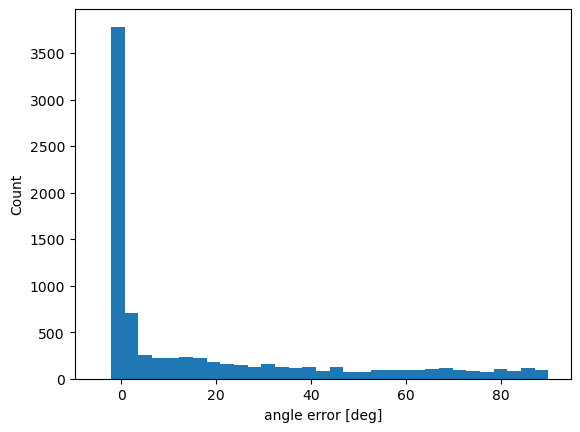

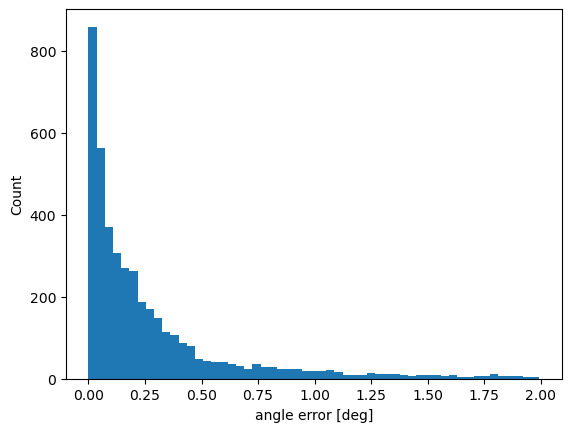

In [9]:
angle_error_list = streak_table['angle_error'][streak_table['angle_error'] != None]

_ = plt.hist(angle_error_list, bins="auto")
plt.xlabel("angle error [deg]")
plt.ylabel("Count")
plt.show()

_ = plt.hist(angle_error_list[(angle_error_list >= 0) & (angle_error_list < 2)], bins="auto")
plt.xlabel("angle error [deg]")
plt.ylabel("Count")
plt.show()

**Along Error**

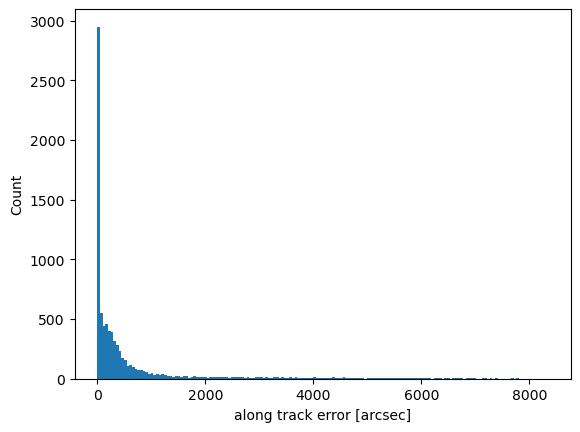

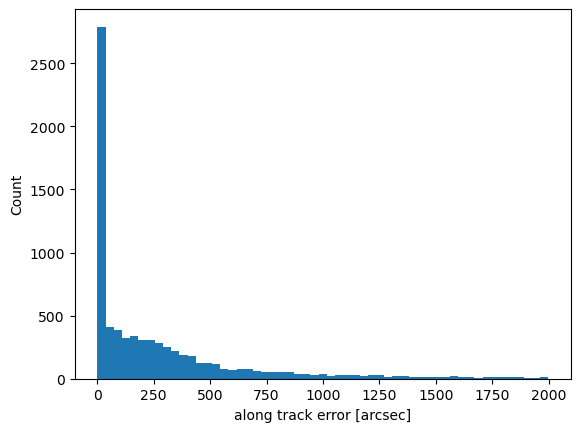

In [10]:
along_error_list = streak_table['along_error'][streak_table['along_error'] != None]

_ = plt.hist(along_error_list, bins="auto")
plt.xlabel("along track error [arcsec]")
plt.ylabel("Count")
plt.show()

_ = plt.hist(along_error_list[(along_error_list < 2000)], bins="auto")
plt.xlabel("along track error [arcsec]")
plt.ylabel("Count")
plt.show()

**Cross error**

/astro/store/shire/kiyoaki/miniconda/envs/499/lib/python3.14/site-packages/numpy/lib/_histograms_impl.py:396: RuntimeWarning: invalid value encountered in greater_equal
  keep = (a >= first_edge)
/astro/store/shire/kiyoaki/miniconda/envs/499/lib/python3.14/site-packages/numpy/lib/_histograms_impl.py:397: RuntimeWarning: invalid value encountered in less_equal
  keep &= (a <= last_edge)
/astro/store/shire/kiyoaki/miniconda/envs/499/lib/python3.14/site-packages/numpy/lib/_histograms_impl.py:837: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/astro/store/shire/kiyoaki/miniconda/envs/499/lib/python3.14/site-packages/numpy/lib/_histograms_impl.py:838: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


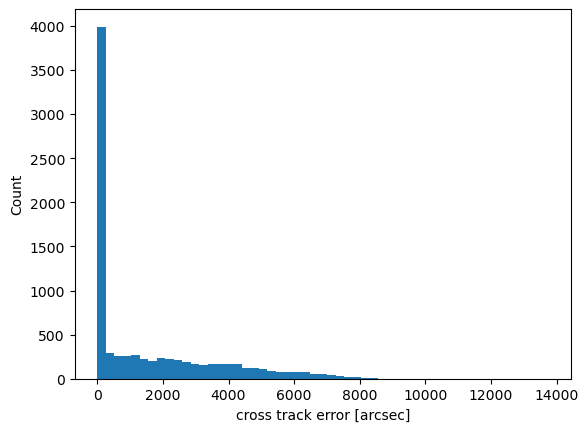

/astro/store/shire/kiyoaki/miniconda/envs/499/lib/python3.14/site-packages/astropy/table/column.py:342: RuntimeWarning: invalid value encountered in less
  result = getattr(super(Column, self), op)(other)


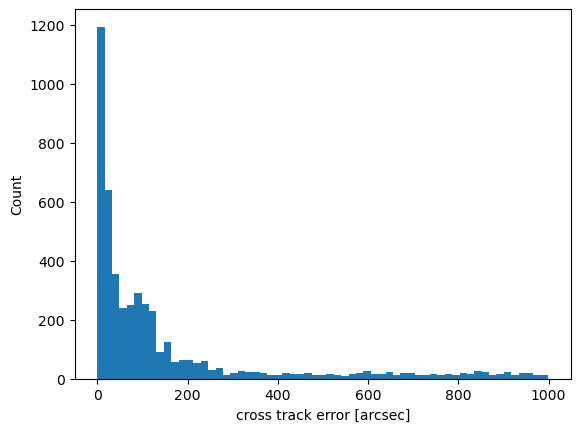

In [11]:
cross_error_list = streak_table['cross_error'][streak_table['cross_error'] != None]

_ = plt.hist(cross_error_list, bins="auto")
plt.xlabel("cross track error [arcsec]")
plt.ylabel("Count")
plt.show()

_ = plt.hist(cross_error_list[(cross_error_list < 1000)], bins="auto")
plt.xlabel("cross track error [arcsec]")
plt.ylabel("Count")
plt.show()

### Starlink

In [12]:
mask = np.char.find(
    np.char.lower(streak_table["name"].astype(str)),
    "starlink"
) >= 0

count = np.sum(mask)
print(f"Streaks identified with StarLink : {count}")

starlink_streak_table = streak_table[mask]

Streaks identified with StarLink : 463


**Angle error**

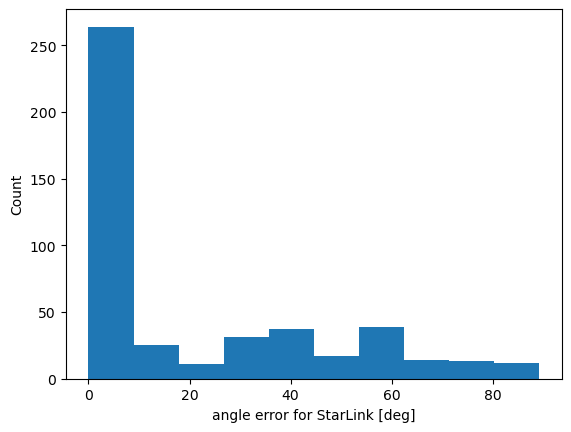

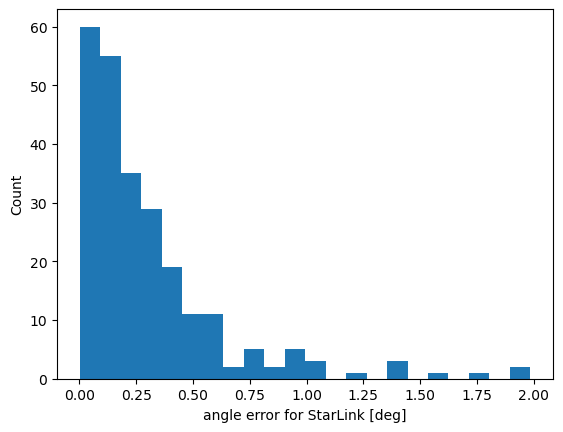

In [10]:
_ = plt.hist(starlink_streak_table['angle_error'], bins="auto")
plt.xlabel("angle error for StarLink [deg]")
plt.ylabel("Count")
plt.show()

_ = plt.hist(starlink_streak_table['angle_error'][(starlink_streak_table['angle_error'] <2)], bins="auto")
plt.xlabel("angle error for StarLink [deg]")
plt.ylabel("Count")
plt.show()

**Along error**

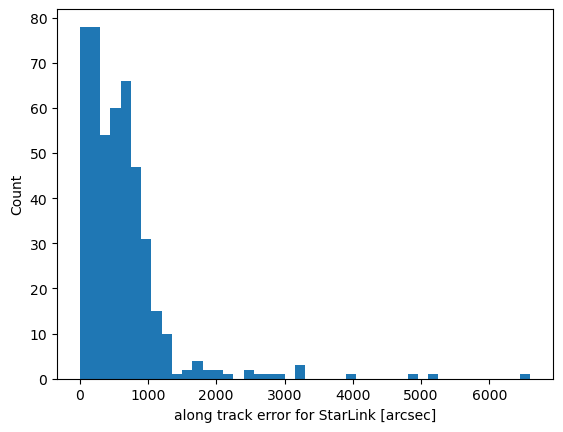

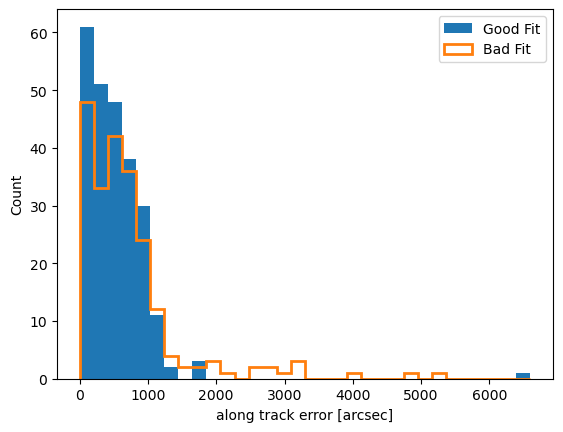

In [11]:
_ = plt.hist(starlink_streak_table['along_error'], bins="auto")
plt.xlabel("along track error for StarLink [arcsec]")
plt.ylabel("Count")
plt.show()

good = starlink_streak_table['along_error'][starlink_streak_table['angle_error'] < 2]
bad  = starlink_streak_table['along_error'][starlink_streak_table['angle_error'] >= 2]

all_data = np.concatenate([good, bad])
bins = np.histogram_bin_edges(all_data, bins=32)

_ = plt.hist(good, bins=bins, label="Good Fit")
_ = plt.hist(bad, bins=bins, histtype='step', linewidth=2, label="Bad Fit")

plt.xlabel("along track error [arcsec]")
plt.ylabel("Count")
plt.legend()
plt.show()

**Cross error**

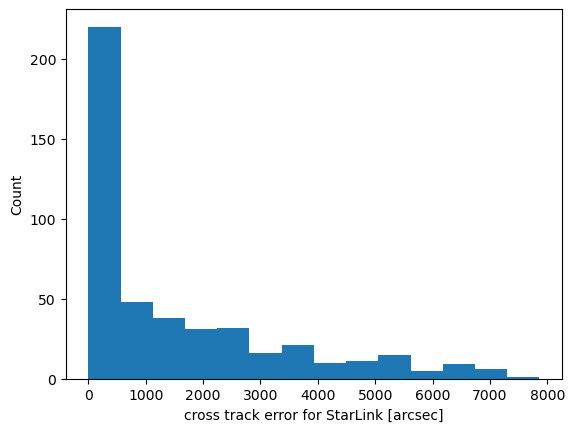

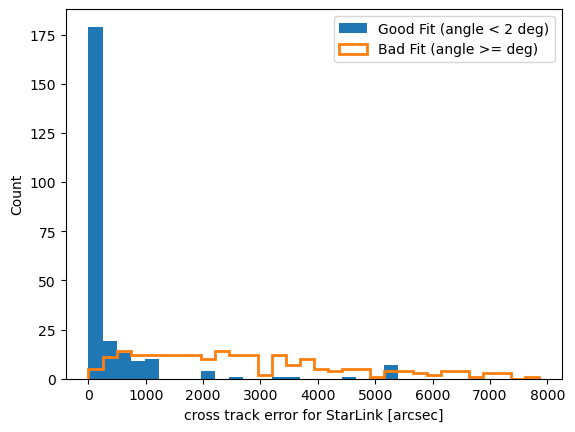

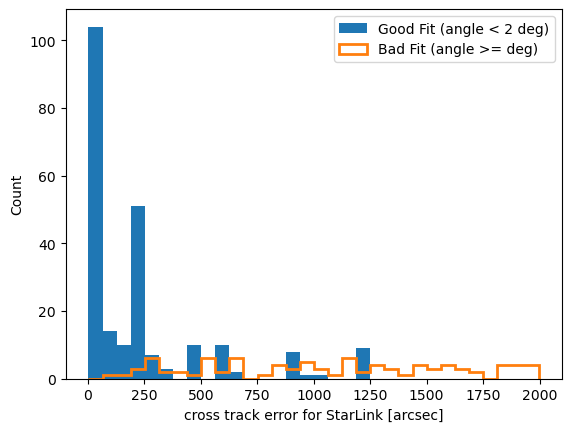

In [16]:
_ = plt.hist(starlink_streak_table['cross_error'], bins="auto")
plt.xlabel("cross track error for StarLink [arcsec]")
plt.ylabel("Count")
plt.show()

good = starlink_streak_table['cross_error'][starlink_streak_table['angle_error'] < 2]
bad  = starlink_streak_table['cross_error'][starlink_streak_table['angle_error'] >= 2]

all_data = np.concatenate([good, bad])
bins = np.histogram_bin_edges(all_data, bins=32)

_ = plt.hist(good, bins=bins, label="Good Fit (angle < 2 deg)")
_ = plt.hist(bad, bins=bins, histtype='step', linewidth=2, label="Bad Fit (angle >= deg)")

plt.xlabel("cross track error for StarLink [arcsec]")
plt.ylabel("Count")
plt.legend()
plt.show()

bins = np.histogram_bin_edges(all_data[all_data<2000], bins=32)
_ = plt.hist(good[good<2000], bins=bins, label="Good Fit (angle < 2 deg)")
_ = plt.hist(bad[bad<2000], bins=bins, histtype='step', linewidth=2, label="Bad Fit (angle >= deg)")

plt.xlabel("cross track error for StarLink [arcsec]")
plt.ylabel("Count")
plt.legend()
plt.show()

**Save session**

In [ ]:
starlink_streak_table_cleaned = starlink_streak_table[(starlink_streak_table['angle_error'] <2) & (starlink_streak_table['along_error'] <2000) & (starlink_streak_table['cross_error'] <2000)]
starlink_streak_table_cleaned.remove_columns(["initial_gauss_y", "initial_amplitude", "initial_ground", "initial_mu", "initial_sigma", "gauss_y", "amplitude", "ground", "mu", "sigma"])
# with open('{0}session/workspace_starlink_streak_table_cleaned.pkl'.format(output_path), 'wb') as f:
with open(PATH_session+path.splitext(path.basename(fname_streak_list))[0]+'_05_starlink.pkl', 'wb') as f:
    pickle.dump(starlink_streak_table_cleaned, f)

**Save result as CSV**

In [ ]:
starlink_streak_table_cleaned.remove_columns(["initial_streak_coord"])
starlink_streak_table_cleaned
starlink_streak_table_cleaned.write(PATH_output+path.splitext(path.basename(fname_streak_list))[0]+'_05_starlink.csv', overwrite=True)

### Al-Az plot

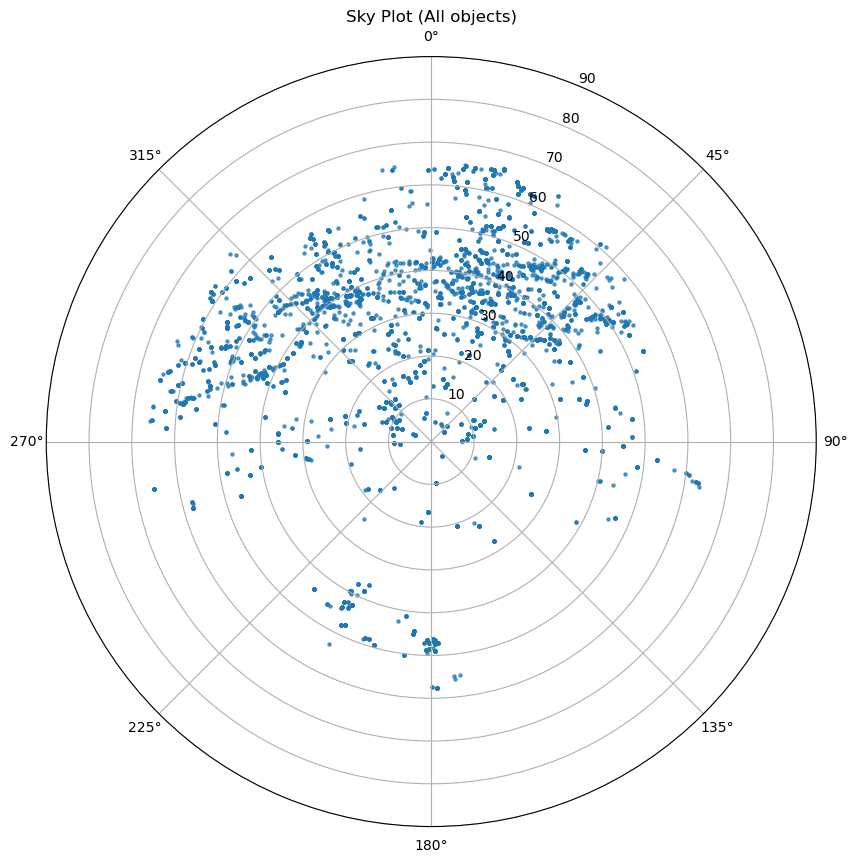

In [ ]:
streak_table = streak_table[streak_table['angle_error'] != None]

az = np.deg2rad(np.array(streak_table[streak_table['angle_error'] < 2]["az"]).astype(float))  # deg → rad
alt = streak_table[streak_table['angle_error'] < 2]["al"].astype(float)
r = 90 - alt

# Plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, polar=True)

ax.scatter(az, r, s=5, alpha=0.7)

# Direction
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

# Range
ax.set_ylim(0, 90)

# Label
ax.set_title("Sky Plot (All objects)")

plt.show()